In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import math
import scipy

ModuleNotFoundError: No module named 'numpy'

In [ ]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', 
          '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] 
#print(mcolors.TABLEAU_COLORS)
#print(colors)

In [ ]:
def read_tof_sums(filename):
    data = np.loadtxt(filename)
    data1 = data[:, 1:].sum(axis=1)
    checksum = data1[4000:None].sum()/data1.sum() # last 100 entries should be zero
    #print(f"checksum = {checksum}")
    return data1[None:4000] 

In [ ]:
path = '/home/fiscfeli/MyData/byProposal/exp_3-14-458_262_pf2ucn/processed/felixf/cascadeTof/'
data_3250 = np.zeros(4000)
for i in range(1, 41+1):
    data_3250 += read_tof_sums(path + 'batch01/T180626_00' +(f'{i:02}')+ '.tof')
for i in range(1, 80+1):
    data_3250 += read_tof_sums(path + 'batch01/T190626_00' +(f'{i:02}')+ '.tof')
#print(data_3250)
#print(f"total counts = {data_3250.sum()}")

In [ ]:
data_30356 = np.zeros(4000)
for i in range(5, 6+1):
    data_30356 += read_tof_sums(path + 'batch02/T190626_00' +(f'{i:02}')+ '.tof')

In [ ]:
data_70874 = read_tof_sums(path + 'batch02/T190626_0007.tof')

In [ ]:
data_89835 = read_tof_sums(path + 'batch02/T190626_0003.tof')

In [ ]:
data_119900 = read_tof_sums(path + 'batch02/T190626_0002.tof')

In [ ]:
data_115440 = read_tof_sums(path + 'batch02/T190626_0004.tof')

In [ ]:
data_150309 = np.zeros(4000)
for i in range(8, 9+1):
    data_150309 += read_tof_sums(path + 'batch02/T190626_00' +(f'{i:02}')+ '.tof')

In [ ]:
data_s631 = [data_3250, data_30356, data_70874, data_89835, data_115440, data_119900, data_150309]
labels_s631 = [325.0, 3035.6, 7087.4, 8983.5, 11544.0, 11990.0, 15030.9]

In [ ]:
def plot_all(data):
    n = len(data)
    if n>1 and n<20:
        fig, axs = plt.subplots(n,1,figsize=(12,9), constrained_layout=True)
        print(axs)
        for i in range(n):
            axs[i].plot(data[i])
            axs[i].set_xlabel("# bin")
            axs[i].set_ylabel("counts")
            axs[i].grid(True)

        axs[0].set_title("325.0")
        axs[1].set_title("3035.6")
        axs[2].set_title("7087.4")
        axs[3].set_title("8983.5")
        axs[4].set_title("11544.0")
        axs[5].set_title("11990.0")
        axs[6].set_title("15030.9")

In [ ]:
testar = [4,5,6,7,2,3,6,5]
oldar = np.array(testar)
print(oldar)
oldar = oldar
newar = oldar[3:None] # gets rid of first 3
print(newar)
newar2 = oldar[None:3] # only leaves first 3
print(newar2)
newar3 = oldar[2:4]
print(newar3)

[4 5 6 7 2 3 6 5]
[7 2 3 6 5]
[4 5 6]
[6 7]


In [ ]:
def plot_bin(bin_data, labels= None):
    for n in range(len(bin_data)):
        y = bin_data[n]
        plt.plot(y, label=str(labels[n]), alpha=0.85**n)


    plt.xlabel("Bin number")
    plt.ylabel("Counts")
    plt.grid(True)
    plt.legend()
    plt.title("Total counts for different switcher positions @EDM")

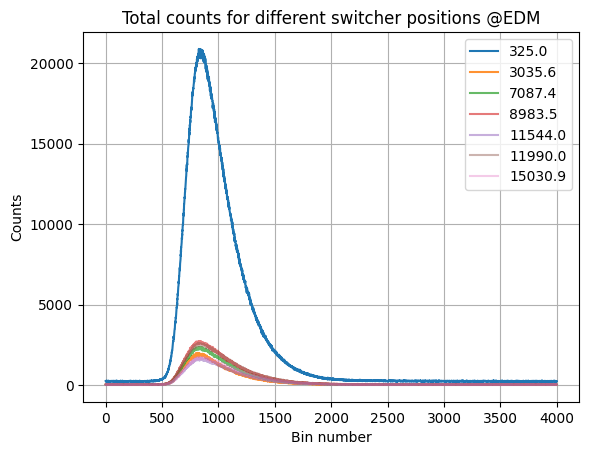

In [ ]:
plot_bin(data_s631, labels_s631)

In [ ]:
def plot_mean_darkcounts(bin_data, labels= None, cut=500, meanpoint=400):
    means = np.zeros((len(bin_data),(2)))

    for n in range(len(bin_data)):
        mean_values = np.zeros(cut)
        std_of_means = np.zeros(cut)
        for i in range(cut):
            if i == 0:
                mean_values[i] = bin_data[n][None:i].sum()
            if i == 1:
                mean_values[i] = bin_data[n][None:i].sum()/i
            if i > 1:
                mean_values[i] = bin_data[n][None:i].sum()/i
                for j in range(i):
                    std_of_means[i] += (bin_data[n][j]-mean_values[j])**2
                std_of_means[i] = math.sqrt(std_of_means[i])/i

        means[n][0]= mean_values[meanpoint]
        means[n][1]= std_of_means[meanpoint]
        y = mean_values
        yerr = std_of_means
        plt.errorbar(range(len(y)), y=y, yerr=yerr, label=str(labels[n]), alpha=0.85**n)
        


    plt.xlabel("Bin number")
    plt.ylabel("Mean of dark counts")
    plt.grid(True)
    plt.legend()
    plt.title("Means of dark counts summed until bin number")
    return means

[[238.9125       1.01166901]
 [ 25.825        0.28723872]
 [ 34.6          0.30046809]
 [ 40.845        0.34449826]
 [ 27.98         0.26227725]
 [ 43.295        0.3536282 ]
 [ 31.8575       0.30271223]]


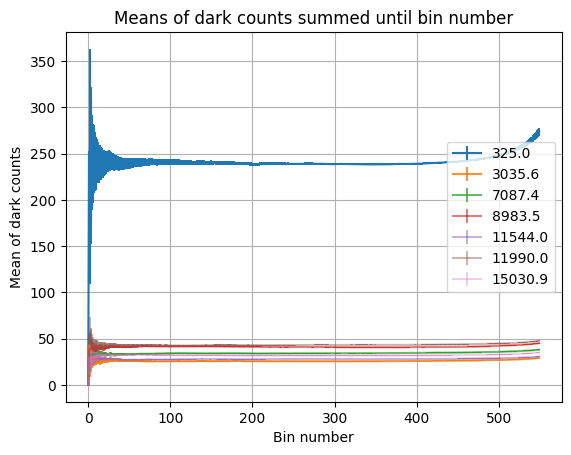

In [ ]:
bin_darkcounts_s631 = plot_mean_darkcounts(data_s631, labels_s631, cut=550)
print(bin_darkcounts_s631)

In [ ]:
def plot_bins_mean(bin_data, bin_darkcounts, labels= None, cut=500, darkcut = 400):
    for n in range(len(bin_data)): 
        darkmeans = np.full(darkcut,bin_darkcounts[n][0])
        darkstds = np.full(darkcut,bin_darkcounts[n][1])
        plt.plot(range(len(bin_data[n][None:cut])), bin_data[n][None:cut], label=str(labels[n]), color=colors[n], alpha=0.7)
        plt.plot(darkmeans, color=colors[n], linestyle = '-')
        plt.fill_between(range(darkcut), darkmeans-bin_darkcounts[n][1], darkmeans+bin_darkcounts[n][1], 
                         facecolor=colors[n], alpha=0.5)


    plt.xlabel("Bin number")
    plt.ylabel("Counts")
    plt.grid(True)
    plt.legend()
    plt.title("Total counts for different switcher positions @EDM")

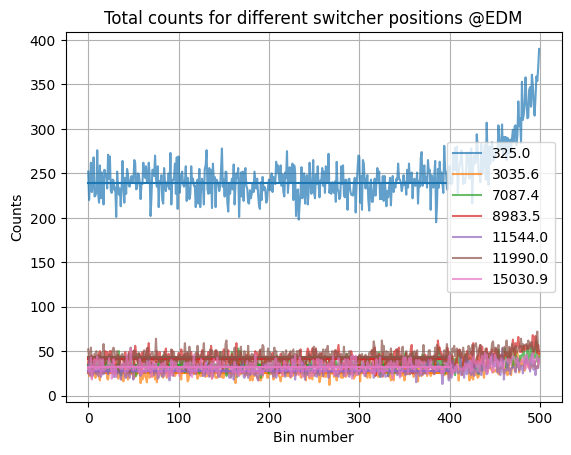

In [ ]:
plot_bins_mean(data_s631, bin_darkcounts_s631, labels_s631)

In [ ]:
def plot_tof(bin_data, bin_darkcounts, labels= None, cut=500):
    s = 631.0 + 8.0 # Chopper 8 mm
    ms_b = 400.0 / 4000.0
    t = []
    for i in range(len(bin_data[0])):
        t.append((i+1)*ms_b)
    t = np.array(t)
    
    v = s / t

    for n in range(len(bin_data)):
        bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        time_N = bin_N/ms_b
        v_N = []
        for i in range(len(v)):
            v_N.append(time_N[i] * s/v[i]**2)

        y = np.array(v_N[cut:None])
        plt.plot(v[cut:None], y/y.sum(), label=str(labels[n]), color=colors[n], alpha=0.85**n)


    plt.xlabel("Velocity [m/s]")
    plt.ylabel("Normalized counts")
    plt.grid(True)
    plt.legend()
    plt.title("ToF Measurement for different switcher positions @EDM")


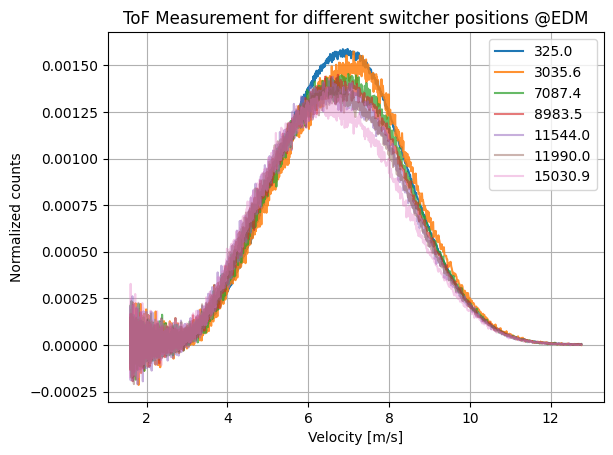

In [ ]:
plot_tof(data_s631, bin_darkcounts_s631, labels_s631)

In [ ]:
def plot_tof_interpolate(bin_data, bin_darkcounts, labels= None, cut=500, deltat = 0.0):
    s = 631.0 + 8.0 # Chopper 8 mm
    ms_b = 400.0 / 4000.0
    t = []
    for i in range(len(bin_data[0])):
        t.append((i+1)*ms_b)
    t = np.array(t)
    
    for n in range(len(bin_data)):
        v = []
        time_N = []
        bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        
        for i in range(len(t)):
            if t[i]-deltat > 0.0:
                v.append(s / (t[i]-deltat))
                time_N.append(bin_N[i]/ms_b)

        v_N = []
        for i in range(len(v)):
            v_N.append(time_N[i] * s/v[i]**2)


        
        y = np.array(v_N[cut:None])
        x = v[cut:None]
        
        # interpolate and find maximum (need to verify this later)
        smoothed = scipy.ndimage.gaussian_filter1d(y, sigma=10)
        # get the maximum
        maxvalue = x[np.argmax(smoothed)]
        print(f"Maximum of {labels[n]} is {maxvalue:.2f} m/s")

        
        plt.plot(x, y/y.sum(), label=str(labels[n]), color=colors[n], alpha=0.85**n)
        plt.plot(x, smoothed/smoothed.sum())


    plt.xlabel("Velocity [m/s]")
    plt.ylabel("Normalized counts")
    plt.grid(True)
    plt.legend()
    plt.title(f"ToF Measurement for different switcher positions @EDM, for s = 631 mm and delta t = {deltat} ms")


Maximum of 325.0 is 8.58 m/s
Maximum of 3035.6 is 8.86 m/s
Maximum of 7087.4 is 8.26 m/s
Maximum of 8983.5 is 8.12 m/s
Maximum of 11544.0 is 7.81 m/s
Maximum of 11990.0 is 7.79 m/s
Maximum of 15030.9 is 7.74 m/s


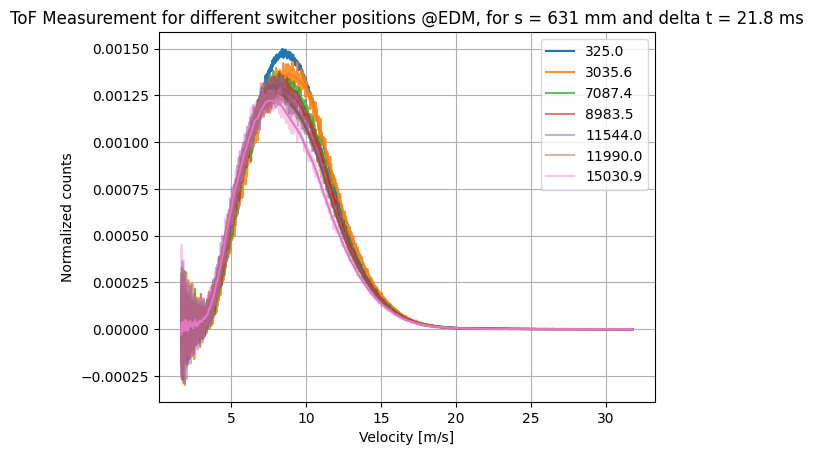

In [ ]:
plot_tof_interpolate(data_s631, bin_darkcounts_s631, labels_s631, cut = 300, deltat = 21.8)

## delta t measurements

In [ ]:
data_EDM_s631 = read_tof_sums(path + 'batch03/T230626_0002.tof')
data_EDM_s460 = read_tof_sums(path + 'batch03/T240626_0001.tof')

data_EDM = [data_EDM_s631, data_EDM_s460]
labels_EDM = ["s = 631 mm", "s = 460 mm"]

[[36.56969697  0.36029677]
 [34.16060606  0.33106458]]


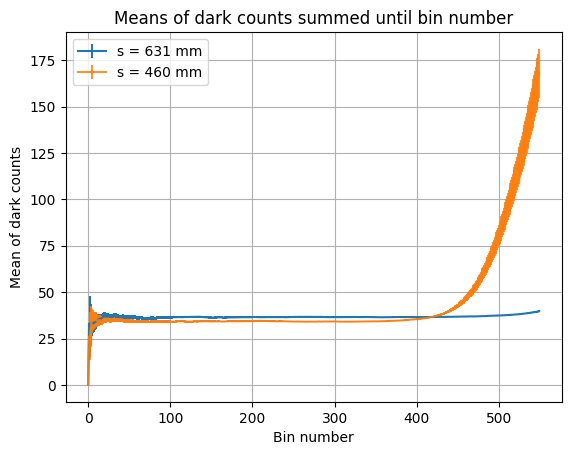

In [ ]:
bin_darkcounts_EDM = plot_mean_darkcounts(data_EDM, labels_EDM, cut=550, meanpoint=330)
print(bin_darkcounts_EDM)

In [ ]:
def plot_toftimes_interpolate(bin_data, bin_darkcounts, labels= None, cut=500, deltat= 0.0):
    s = 631.0 + 8.0 # Chopper 8 mm
    ms_b = 400.0 / 4000.0
    t = []
    for i in range(len(bin_data[0])):
        t.append((i+1)*ms_b)
    t = np.array(t)

    for n in range(len(bin_data)):
        bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        teff = []
        v = []
        time_N = []
        bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        
        for i in range(len(t)):
            if t[i]-deltat > 0.0:
                teff.append(t[i]-deltat)
                v.append(s / (t[i]-deltat))
                time_N.append(bin_N[i]/ms_b)
        v_N = []
        for i in range(len(v)):
            v_N.append(time_N[i] * s/v[i]**2)


        
        #y = np.array(v_N[cut:None])
        y = np.array(time_N)
        #x = v[cut:None]
        x = teff
        
        # interpolate and find maximum (need to verify this later)
        smoothed = scipy.ndimage.gaussian_filter1d(y, sigma=10)
        # get the maximum
        maxvalue = x[np.argmax(smoothed)]
        print(f"Maximum of {labels[n]} is {maxvalue:.2f} s")

        
        plt.plot(x, y/y.sum(), label=str(labels[n]), color=colors[n], alpha=0.85**n)
        plt.plot(x, smoothed/smoothed.sum())


    plt.xlabel("Time - delta t [ms]")
    plt.ylabel("Normalized counts")
    plt.grid(True)
    plt.legend()
    plt.title(f"ToF Measurement for different tube lengths @EDM and delta t = {deltat} ms")


Maximum of s = 631 mm is 83.70 s
Maximum of s = 460 mm is 68.90 s


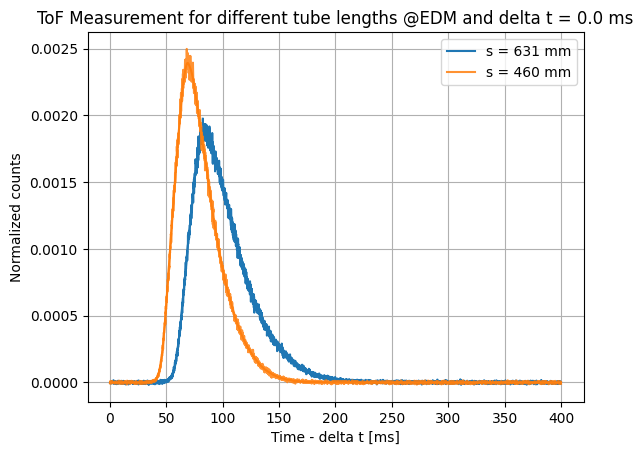

In [ ]:
plot_toftimes_interpolate(data_EDM, bin_darkcounts_EDM, labels_EDM, deltat= 21.8)

In [ ]:
# calculate delta t with the maximum values of the time distribution
t631=83.7
t460=68.9
s631=631+8.0
s460=460+8.0
print(f"delta t = {(t631*s460 - t460*s631)/(s460-s631)} ms")

sEDM = [s631, s460]

delta t = 28.394736842105306 ms


In [ ]:
def plot_tof_interpolate2(bin_data, bin_darkcounts, s, labels= None, cut=400, deltat = 0.0):
    s = np.array(s) #+ 8.0 # Chopper 8 mm
    ms_b = 400.0 / 4000.0
    t = []
    for i in range(len(bin_data[0])):
        t.append((i+1)*ms_b)
    t = np.array(t)
    print(t-deltat)


    for n in range(len(bin_data)):
        v = []
        time_N = []
        bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        
        for i in range(len(t)):
            if t[i]-deltat > 0.0:
                v.append(s[n] / (t[i]-deltat))
                time_N.append(bin_N[i]/ms_b)
        v_N = []
        for i in range(len(v)):
            v_N.append(time_N[i] * s[n]/v[i]**2)


        
        y = np.array(v_N[cut:None])
        x = v[cut:None]
        
        # interpolate and find maximum (need to verify this later)
        smoothed = scipy.ndimage.gaussian_filter1d(y, sigma=10)
        # get the maximum
        maxvalue = x[np.argmax(smoothed)]
        print(f"Maximum of {labels[n]} is {maxvalue:.2f} m/s")

        
        plt.plot(x, y, label=str(labels[n]), color=colors[n], alpha=0.85**n)
        plt.plot(x, smoothed)


    plt.xlabel("Velocity [m/s]")
    plt.ylabel("Counts")
    plt.grid(True)
    plt.legend()
    plt.title(f"delta t = {deltat} ms corrected ToF Measurement")


[-28.3 -28.2 -28.1 ... 371.4 371.5 371.6]
Maximum of s = 631 mm is 8.43 m/s
Maximum of s = 460 mm is 8.25 m/s


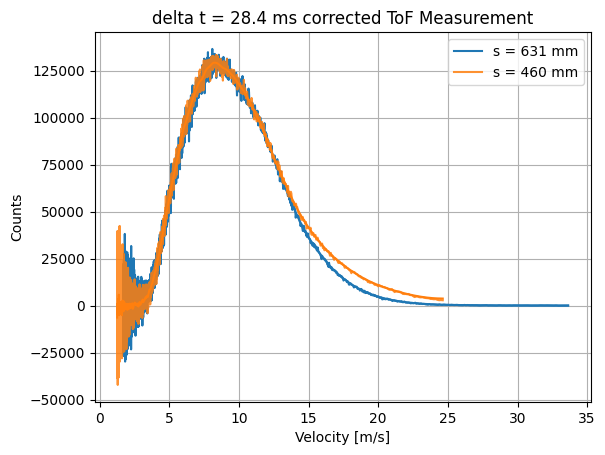

In [ ]:
plot_tof_interpolate2(data_EDM, bin_darkcounts_EDM, sEDM, labels_EDM, cut = 190, deltat= 28.4)

In [ ]:
def tof_chisquared(bin_data, bin_darkcounts, s, labels= None, cut=400, deltat = 0.0):
    s = np.array(s) #+ 8.0 # Chopper 8 mm
    ms_b = 400.0 / 4000.0
    t = []
    for i in range(len(bin_data[0])):
        t.append((i+1)*ms_b)
    t = np.array(t)

    yTheory=[]
    yExp =[]
    xExp =[]

    for n in range(len(bin_data)):
        #v = s[n] / (t-deltat)
        #bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        #time_N = bin_N/ms_b

        v = []
        time_N = []
        bin_N = np.array(bin_data[n]) - bin_darkcounts[n][0]
        for i in range(len(t)):
            if t[i]-deltat > 0.0:
                v.append(s[n] / (t[i]-deltat))
                time_N.append(bin_N[i]/ms_b)
        
        v_N = []
        for i in range(len(v)):
            v_N.append(time_N[i] * s[n]/v[i]**2)

        y = np.flip(np.array(v_N[cut:None]))
        x = np.flip(v[cut:None])
        
        # interpolate and find maximum (need to verify this later)
        #smoothed = scipy.ndimage.gaussian_filter1d(y, sigma=10)
        # get the maximum
        #maxvalue = x[np.argmax(smoothed)]
        #print(f"Maximum of {labels[n]} is {maxvalue:.2f} m/s")
        
        if n == 0:
            yExp = y
            xExp = x
        if n == 1:
            ysmoothed = scipy.ndimage.gaussian_filter1d(y, sigma=10) #smoothed
            yTheory = np.interp(xExp, x, ysmoothed) # interpolated
            #plt.plot(x,ysmoothed, label="TheorySmoothed")
    plot_interpolation = False
    if plot_interpolation == True:
        plt.plot(xExp, yTheory, label="s = 631 mm, Interpolated")
        plt.plot(xExp, yExp, label="s = 460 mm", alpha = 0.5)
        plt.xlabel("Velocity [m/s]")
        plt.ylabel("Counts")
        plt.grid(True)
        plt.legend()
        plt.title("Interpolate one of the datasets")
        
    
    # do chi squared in area v [3 m/s to 15 m/s]
    newV = []
    newNV631 = []
    newNV460 = []
    Chisq = 0.0
    for i in range(len(xExp)):
        if xExp[i] > 3.0 and xExp[i] <15.0:
            newV.append(xExp[i])
            newNV631.append(yTheory[i])
            newNV460.append(yExp[i])
            Chisq += (yTheory[i]-yExp[i])**2/yTheory[i]

    plot_newRange = False
    if plot_newRange == True:
        plt.plot(newV, newNV631, label="s = 631 mm, Interpolated")
        plt.plot(newV, newNV460, label="s = 460 mm", alpha = 0.5)
        plt.xlabel("Velocity [m/s]")
        plt.ylabel("Counts")
        plt.grid(True)
        plt.legend()
        plt.title("Interpolate one of the datasets")
    #print(f"Chi squared = {Chisq:.2f}")
    return Chisq
    

delta t = 22 ms
delta t = 23 ms
delta t = 24 ms
delta t = 25 ms
delta t = 26 ms
delta t = 27 ms
delta t = 28 ms
delta t = 29 ms
delta t = 30 ms
delta t = 31 ms
delta t = 32 ms
delta t = 33 ms
delta t = 34 ms


Text(0.5, 1.0, 'Chi squared test for different delta t')

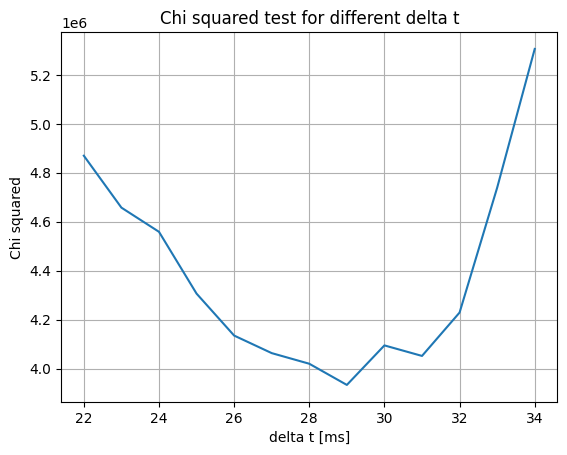

In [ ]:
Chisq = []
dts = range(22,35)
for i in dts:
    print(f"delta t = {i} ms")
    Chisq.append(tof_chisquared(data_EDM, bin_darkcounts_EDM, sEDM, labels_EDM, deltat= i))
plt.plot(dts,Chisq)
plt.xlabel("delta t [ms]")
plt.ylabel("Chi squared")
plt.grid(True)
plt.title("Chi squared test for different delta t")



# minuit Cern, anzahl fitparameter delta t, norm
#tof_chisquared(data_EDM, bin_darkcounts_EDM, sEDM, labels_EDM, deltat= 28.4)